## 0. Helper functions

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import time
import os
import joblib
from copy import deepcopy

def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

## 1. Define file path and load data

In [6]:
filebeginning = '20250218-1308-12_scan10_3K_70mT_Bnv_sFC_Rabi_autosave_NbTiN_Paris_S1_A-F17-26_' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\AttoDRY2200_Pi3_SPM\\'
filepath = path + filebeginning

with open(filepath+'qafm_array_raw.pickle', 'rb') as f:
    qafm_data = pickle.load(f)
with open(filepath+'pulsed_array_raw.pickle', 'rb') as f:
    pulsed_data = pickle.load(f)

Traceback (most recent call last):
  File "C:\Users\yy3\Documents\Software\qudi\logic\jupyterkernel\qzmqkernel.py", line 679, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-6-7d6c2934db1f>", line 12, in <module>
    pulsed_data = pickle.load(f)
EOFError: Ran out of input


## 2. Determine bias field

In [11]:
#Analyse bias field
#Gathering data from dictonary
podrm_file = ''+'.dat' #Needed if not given yet

if 'b_field_bias' in pulsed_data['pulsed_fw'].keys():
    b_field_bias = pulsed_data['pulsed_fw']['b_field_bias']
    res_freq_bias = pulsed_data['pulsed_fw']['res_freq_bias']
    print('Bias field: ',b_field_bias,'T')
    
else:
    podmr_file_year = podrm_file[0:4]
    podmr_file_month = podrm_file[4:6]
    podmr_file_day = podrm_file[6:8]
    podmr_path = 'G:\\Data\\Qudi_Data\\'+podmr_file_year+'\\'+podmr_file_month+'\\'+podmr_file_year+podmr_file_month+podmr_file_day+'\\PODMR\\'
    podmr_filepath = podmr_path + podrm_file
    data_raw = np.loadtxt(podmr_filepath).T
    var_list,data = (data_raw[0],data_raw[1])

    gyro_nv = 28e9 #in Hz/T
    e_field = 0 #in Hz
    zero_field = 2.88e9 #in Hz, watch the Temperature

    mode = 'gaussian_dip'
    gslac = False
    left = False

    #Determine fit

    if mode == 'double':
        fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
        lm,_ = fitlogic.make_lorentziandouble_model()

    elif mode == 'N15':
        fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
        lm,_ = fitlogic.make_lorentziandouble_model()

    elif mode == 'N14':
        fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
        lm,_ = fitlogic.make_lorentziandouble_model()

    elif mode == 'gaussian_dip':
            fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
            lm,_ = fitlogic.make_gaussian_model()

    else:    
        fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
        lm,_ = fitlogic.make_lorentzian_model()

    # print(fit.fit_report())
    bias_res_freq = fit.params['center'].value

    if gslac == True and left == True:
        b_field_bias = np.sqrt(abs(bias_res_freq + zero_field)**2 - e_field**2) / gyro_nv
    else:
        b_field_bias = np.sqrt(abs(bias_res_freq - zero_field)**2 - e_field**2) / gyro_nv

    #Plot Data an
    plt.plot(var_list,data,'bo')

    x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
    plt.plot(x, lm.eval(fit.params, x=x),'r-')

    plt.show()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1
    print('Bias field: ',b_field_bias,'T')
    print("FWHM: ",fwhm_bias,'MHz')
    print("Contrast: ",contrast_bias,'%')

Bias field:  0.06185206671763475 T


## 3. Fit PODMR spectrum scan with chosen lorentzian/gaussian (expensive-ish)

In [13]:
#Analyse scan with PODMR
#Gathering data from dictonary

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

gslac = False
left = True

#Define the measured peak properties
mode = 'gaussian_dip'

coord0_num = qafm_data['Height(Dac)_fw']['params']['coord0_num (#)']
coord1_num = qafm_data['Height(Dac)_fw']['params']['coord1_num (#)']
b_field = np.zeros((coord1_num,coord0_num))
res_freq = np.zeros((coord1_num,coord0_num))
res_freq_err = np.zeros((coord1_num,coord0_num))
fwhm = np.zeros((coord1_num,coord0_num))
fwhm_err = np.zeros((coord1_num,coord0_num))
contrast = np.zeros((coord1_num,coord0_num))
contrast_err = np.zeros((coord1_num,coord0_num))
error_array = np.zeros((coord1_num,coord0_num))

b_field_done = False
res_freq_done = False
if 'Tracking method' in qafm_data['Height(Dac)_fw']['params'].keys():
    if qafm_data['Height(Dac)_fw']['params']['Tracking method'] == 'Two point':
        if 'b_field_fw' in qafm_data.keys():
            b_field = qafm_data['b_field_fw']['data']
            b_field_done = True
            res_freq_done = True
        else:
            res_freq = qafm_data['fit_param_fw']['data']
            res_freq_done = True
    elif qafm_data['Height(Dac)_fw']['params']['Tracking method'] == 'Full PODMR':
        data = pulsed_data['pulsed_fw']['data_tracking']
        var_list = pulsed_data['pulsed_fw']['var_list_tracking']
else:
    if 'var_list' in pulsed_data['pulsed_fw'].keys():
        data = pulsed_data['pulsed_fw']['data']
        var_list = pulsed_data['pulsed_fw']['var_list']
    elif qafm_data['Height(Dac)_fw']['params']['Parameters for'] != 'QAFM arb. sequence measurement':
        data = pulsed_data['pulsed_fw']['data']
        var_list = pulsed_data['pulsed_fw']['coord2_arr']
    else:
        b_field = np.zeros_like(qafm_data['Height(Dac)_fw']['data'])
        b_field_done = True
        res_freq_done = True
                                
if not res_freq_done:
    if var_list.ndim == 3:
        tracking = True
    else:
        tracking = False
        var = var_list

    for i in range(coord1_num):
        for j in range(coord0_num):
            if np.sum(data[i,j]) == 0:
                res_freq[i,j] = res_freq_bias
                fwhm[i,j] = 0
                fwhm_err[i,j] = 0
                contrast[i,j] = 0
                contrast_err[i,j] = 0
                continue
            if tracking:
                var = var_list[i,j]
            #Determine fit
            try:
                if mode == 'double':
                    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
                    res_freq[i,j] = fit.params['l0_center'].value + (fit.params['l1_center'].value-fit.params['l0_center'].value)/2
                    fwhm[i,j] = 0
                    fwhm_err[i,j] = 0
                    contrast[i,j] = 0
                    contrast_err[i,j] = 0
                    
                elif mode == 'N15':
                    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
                    res_freq[i,j] = fit.params['l0_center'].value + (fit.params['l1_center'].value-fit.params['l0_center'].value)/2
                    fwhm[i,j] = 0
                    fwhm_err[i,j] =0
                    contrast[i,j] = 0
                    contrast_err[i,j] = 0
                    
                elif mode == 'N14':
                    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
                    res_freq[i,j] = fit.params['l0_center'].value
                    fwhm[i,j] = 0
                    fwhm_err[i,j] = 0
                    contrast[i,j] = 0
                    contrast_err[i,j] = 0

                elif mode == 'gaussian_dip':
                    fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
                    res_freq[i,j] = fit.params['center'].value
                    res_freq_err[i,j] = fit.params['center'].stderr
                    fwhm[i,j] = fit.params['fwhm'].value
                    fwhm_err[i,j] = fit.params['fwhm'].stderr
                    contrast[i,j] = fit.params['contrast'].value*-1
                    contrast_err[i,j] = fit.params['contrast'].stderr*-1

                else:    
                    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var,data[i,j],estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
                    res_freq[i,j] = fit.params['center'].value
                    fwhm[i,j] = fit.params['fwhm'].value
                    fwhm_err[i,j] = fit.params['fwhm'].stderr
                    contrast[i,j] = fit.params['contrast'].value*-1
                    contrast_err[i,j] = fit.params['contrast'].stderr*-1

            except:
                error_array[i,j] = 1
                
if not b_field_done:

    if gslac == True and left == True:
        b_field = np.sqrt(abs(res_freq + zero_field)**2 - e_field**2) / gyro_nv - b_field_bias
    else:
        b_field = np.sqrt(abs(res_freq - zero_field)**2 - e_field**2) / gyro_nv - b_field_bias

In [14]:
#Plot analysed Data from PODMR
x_gwy = qafm_data['Height(Dac)_fw']['coord0_arr']
y_gwy = qafm_data['Height(Dac)_fw']['coord1_arr']
x = x_gwy*10**6
y = y_gwy*10**6

#for gwyddion
dataobj = {}

## TOPO ##
#for gwyddion
dataobj['Topography'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['Height(Dac)_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'm',
                            'nice_name': 'Topography'
    
                        }

## COUNTS ##
#for gwyddion
dataobj['Fluorescence'] = {
                            'coord0_arr':x_gwy,
                            'coord1_arr':y_gwy,
                            'data':qafm_data['counts_fw']['data'],
                            'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                            'xy_units': 'm',                                                
                            'si_units': 'c/s',
                            'nice_name': 'Fluorescence'
    
                        }

## BFIELD CORR mT ##
data = b_field # b_field_bias is found earlier from OOC fit. In tesla
#for gwyddion
if np.sum(data) != 0:
    dataobj['Stray Field'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': 'T',
                                'nice_name': 'Stray Field: B_NV - B_bias'

                            }

## FWHM ##
data = fwhm 

#for gwyddion
if np.sum(data) != 0:
    dataobj['Linewidth'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': 'Hz',
                                'nice_name': 'Linewidth'

                            }


## Contrast ##
data = contrast

#for gwyddion
if np.sum(data) != 0:
    dataobj['Contrast'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': '',
                                'nice_name': 'Contrast'

                            }

## 4. Analyse arb. pulsed measurement

In [30]:
#Define fit function
mode = 'sin_exp'

coord0_num = qafm_data['Height(Dac)_fw']['params']['coord0_num (#)']
coord1_num = qafm_data['Height(Dac)_fw']['params']['coord1_num (#)']

fit_arg_0 = np.zeros((coord1_num,coord0_num))
fit_arg_0_err = np.zeros((coord1_num,coord0_num))
fit_arg_1 = np.zeros((coord1_num,coord0_num))
fit_arg_1_err = np.zeros((coord1_num,coord0_num))
fit_arg_2 = np.zeros((coord1_num,coord0_num))
fit_arg_2_err = np.zeros((coord1_num,coord0_num))

# if qafm_data['Height(Dac)_fw']['params']['Parameters for'] == 'QAFM arb. sequence measurement':
alternating = False #pulsed_data['pulsed_fw']['params']['alternating']
if alternating:
    data = pulsed_data['pulsed_fw']['data_delta']
else:
    data = pulsed_data['pulsed_fw']['data']
var_list = pulsed_data['pulsed_fw']['coord2_arr']
                
for i in range(coord1_num):
    for j in range(coord0_num):
        if np.sum(data[i,j]) == 0:
            continue
        #Determine fit
        try:
            if mode == 'sin_exp':
                fit = fitlogic.make_sineexponentialdecay_fit(var_list,data[i,j],estimator=fitlogic.estimate_sineexponentialdecay)
                fit_arg_0[i,j] = 1/fit.params['frequency'].value
                fit_arg_0_err[i,j] = 1/(fit.params['frequency'].value)**2*fit.params['frequency'].stderr
                nice_name_0 = 'Sin_exp_period'
                si_unit_0 = 's'
                fit_arg_1[i,j] = ((2*fit.params['amplitude'].value)/(fit.params['offset'].value+fit.params['amplitude'].value)*100)
                fit_arg_1_err[i,j] = (np.abs((2*fit.params['amplitude'].value) /
                                            (fit.params['offset'].value+fit.params['amplitude'].value)**2 *
                                             fit.params['offset'].stderr) +
                                             np.abs((2/(fit.params['offset'].value +
                                             fit.params['amplitude'].value) + (2*fit.params['amplitude'].value) /
                                             (fit.params['offset'].value + fit.params['amplitude'].value)**2) *
                                             fit.params['amplitude'].stderr))*100
                nice_name_1 = 'Sin_exp_contrast'
                si_unit_1 = '%'
        except:
            pass

In [34]:
## fit_arg_0 ##
data = fit_arg_0
#for gwyddion
if np.sum(data) != 0:
    dataobj['fit_arg_0'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': si_unit_0,
                                'nice_name': nice_name_0

                            }

## fit_arg_1 ##
data = fit_arg_1
#for gwyddion
if np.sum(data) != 0:
    dataobj['fit_arg_1'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': si_unit_1,
                                'nice_name': nice_name_1

                            }

## fit_arg_2 ##
data = fit_arg_2
#for gwyddion
if np.sum(data) != 0:
    dataobj['fit_arg_2'] = {
                                'coord0_arr':x_gwy,
                                'coord1_arr':y_gwy,
                                'data':data,
                                'params': {'coord0_start': x_gwy[0],'coord0_stop': x_gwy[-1],'coord1_start': y_gwy[0],'coord1_stop': y_gwy[-1]},
                                'xy_units': 'm',                        
                                'si_units': si_unit_2,
                                'nice_name': nice_name_2

                            }

## 5. Save to new gwyddion file - data defined in previous cell

In [35]:
"""save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """
from logic import gwyfile as gwy
save_obj_to_gwyddion(dataobj=dataobj,filename=filepath+'QAFM_jupyter_corrected.gwy')

## 6. Save data to pickle

In [12]:
#Save calculated B field to pickel
pulsed_array = pulsed_data
pulsed_array['pulsed_fw']['b_field'] = b_field
pulsed_array['pulsed_fw']['b_field_bias'] = b_field_bias
if np.sum(fwhm) != 0:
    pulsed_array['pulsed_fw']['fwhm'] = fwhm
    pulsed_array['pulsed_fw']['fwhm_err'] = fwhm_err
    pulsed_array['pulsed_fw']['fwhm_nice_name'] = 'ODMR FWHM'
    pulsed_array['pulsed_fw']['fwhm_si_unit'] = 'Hz'
    
if np.sum(contrast) != 0:
    pulsed_array['pulsed_fw']['contrast'] = contrast
    pulsed_array['pulsed_fw']['contrast_err'] = contrast_err
    pulsed_array['pulsed_fw']['contrast_nice_name'] = 'ODMR contrast'
    pulsed_array['pulsed_fw']['contrast_si_unit'] = ''
    
if np.sum(fit_arg_0) != 0:
    pulsed_array['pulsed_fw']['fit_arg_0'] = fit_arg_0
    pulsed_array['pulsed_fw']['fit_arg_0_err'] = fit_arg_0_err
    pulsed_array['pulsed_fw']['fit_arg_0_nice_name'] = nice_name_0
    pulsed_array['pulsed_fw']['fit_arg_0_si_unit'] = si_unit_0
    
if np.sum(fit_arg_1) != 0:
    pulsed_array['pulsed_fw']['fit_arg_1'] = fit_arg_1
    pulsed_array['pulsed_fw']['fit_arg_1_err'] = fit_arg_1_err
    pulsed_array['pulsed_fw']['fit_arg_1_nice_name'] = nice_name_1
    pulsed_array['pulsed_fw']['fit_arg_1_si_unit'] = si_unit_1
    
if np.sum(fit_arg_2) != 0:
    pulsed_array['pulsed_fw']['fit_arg_2'] = fit_arg_2
    pulsed_array['pulsed_fw']['fit_arg_2_err'] = fit_arg_2_err
    pulsed_array['pulsed_fw']['fit_arg_2_nice_name'] = nice_name_2
    pulsed_array['pulsed_fw']['fit_arg_2_si_unit'] = si_unit_2
    
with open(filepath+'pulsed_array_jupyter_analysed.pickle', 'wb') as f:
    pickle.dump(pulsed_array, f)

In [13]:
pulsed_data['pulsed_fw'].keys()

dict_keys(['data', 'data_alternating', 'data_std', 'data_alternating_std', 'data_fit', 'data_alternating_fit', 'data_delta', 'coord0_arr', 'coord1_arr', 'coord2_arr', 'measured_units', 'scale_fac', 'si_units', 'nice_name', 'params', 'display_range', 'data_tracking', 'data_std_tracking', 'var_list_tracking', 'data_bias', 'var_list_bias', 'gslac_bias', 'res_freq_bias', 'b_field_bias', 'b_field', 'fwhm', 'fwhm_err', 'fwhm_nice_name', 'fwhm_si_unit', 'contrast', 'contrast_err', 'contrast_nice_name', 'contrast_si_unit', 'fit_arg_0', 'fit_arg_0_err', 'fit_arg_0_nice_name', 'fit_arg_0_si_unit', 'fit_arg_1', 'fit_arg_1_err', 'fit_arg_1_nice_name', 'fit_arg_1_si_unit'])

In [69]:
pulsed_array_raw = {'data_raw': pulsed_data['pulsed_fw']['data_raw'],
                   'data_raw_tracking': pulsed_data['pulsed_fw']['data_raw_tracking']}
del pulsed_data['pulsed_fw']['data_raw']
del pulsed_data['pulsed_fw']['data_raw_tracking']

In [8]:
with open(filepath+'pulsed_array_raw_data_raw.pickle', 'wb') as f:
    joblib.dump(pulsed_array_raw_tracking, f, compress = 3)

## View current scan data

In [3]:
qafm_data = deepcopy(afm_scanner_logic._qafm_scan_array)
pulsed_data = deepcopy(afm_scanner_logic._pulsed_scan_array)

In [5]:
afm_scanner_logic._qafm_scan_array = qafm_data
afm_scanner_logic._pulsed_scan_array = pulsed_data

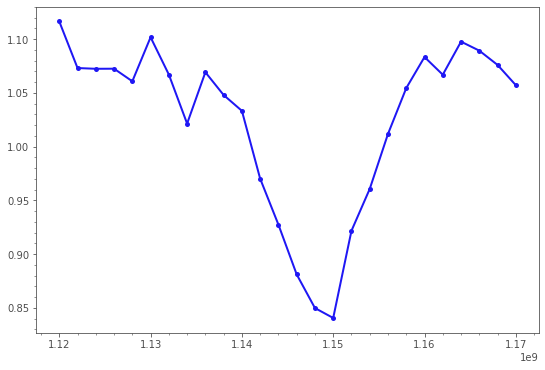

In [4]:
#Show pulsed data. If pulsed data is tacken with resonance tracking, show_arb_pulse_data allows to switch between the datasets
show_arb_pulse_data = False
x_start = 0
x_stop = 0
y_start = 0
y_stop = 0


if 'data_tracking' in pulsed_data['pulsed_fw'].keys():
    if show_arb_pulse_data:
        data = pulsed_data['pulsed_fw']['data']
        var_list = pulsed_data['pulsed_fw']['coord2_arr']
    else:
        data = pulsed_data['pulsed_fw']['data_tracking']
        var_list = pulsed_data['pulsed_fw']['var_list_tracking']
elif 'var_list' in pulsed_data['pulsed_fw'].keys():
    data = pulsed_data['pulsed_fw']['data']
    var_list = pulsed_data['pulsed_fw']['var_list']
else:
    data = pulsed_data['pulsed_fw']['data']
    var_list = pulsed_data['pulsed_fw']['coord2_arr']

if var_list.ndim == 3:
    tracking = True
else:
    tracking = False
    var = var_list

x_pos = np.arange(x_start, x_stop+1,1)
y_pos = np.arange(y_start, y_stop+1,1)
    
offset = 0
offset_add = 0.1
    
for i in y_pos:
    for j in x_pos:
        if tracking:
            var = var_list[i,j]
        fit = fitlogic.make_sineexponentialdecay_fit(var,data[i,j],estimator=fitlogic.estimate_sineexponentialdecay)
        plt.plot(var,data[i,j]+offset,'o-')
        offset = offset+offset_add


plt.show()

In [8]:
filebeginning = '20250218-1308-12_scan10_3K_70mT_Bnv_sFC_Rabi_autosave_NbTiN_Paris_S1_A-F17-26_' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\AttoDRY2200_Pi3_SPM\\'
filepath = path + filebeginning

with open(filepath+'qafm_array_raw.pickle', 'wb') as f:
    pickle.dump(afm_scanner_logic._qafm_scan_array, f)
with open(filepath+'pulsed_array_raw.pickle', 'wb') as f:
    pickle.dump(afm_scanner_logic._pulsed_scan_array, f)

Traceback (most recent call last):
  File "C:\Users\yy3\Documents\Software\qudi\logic\jupyterkernel\qzmqkernel.py", line 679, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-8-e62e2ba76167>", line 12, in <module>
    pickle.dump(afm_scanner_logic._pulsed_scan_array, f)
MemoryError
